In [19]:
import json
import operator
import re
from pathlib import Path
from typing import TypedDict, Annotated

from langchain_ollama import ChatOllama
from langchain_core.tools import tool
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langgraph.graph import StateGraph, START, END

llm      = ChatOllama(model="llama3.2:latest", temperature=0)
DATA_DIR = Path("./data")

print(f"✅ Setup")


✅ Setup


In [20]:
# Schema di stato condiviso tra tutti i nodi
class StatoRichiesta(TypedDict, total=False):
    # Input
    richiesta:              str     # messaggio originale del cliente
    claim_id:               str     # ID della pratica
    customer_policy_id:     str     # ID dell'assicurazione del cliente
    customer_loss_type:     str     # tipo di pratica dichiarata dall'utente (incidente, furto, allagamento)
    estimated_damage:       int     # valore stimato dell'indennizzo
    documents:              list    # lista dei documenti inviati dal cliente (come stringhe)

    # Risultati intermedi
    customer_name:          str     # prende il nome del cliente (probabilmente inutile, poi vediamo)
    risk_tier:              str     # possibile approfondimento futuro (sale con il numeri di incidenti)
    policy_id:              str     # prende l'assicurazione effettiva (bisogna verificare che sia effettivamente posseduta dal cliente)
    product:                str     # prodotto assicurato (casa / macchina)
    coverage:               str     # da cosa ti copre l'assicurazione (bisogna verificare anche questo)
    deductible:             int     # franchigia (parte che il cliente deve pagare comunque)
    max_claims:             int     # tetto massimo coperto (probabilmente oltre questa soglia il perito non può agisce)
    active:                 bool    # flag che indica se l'assicurazione è attivo o meno (fondamentale)

    # Approfondimento di loss_type
    loss_type:              str     # tipo di pratica
    required_documents:     list    # lista dei documenti richiesti dall'assicurazione (come stringhe)
    automatic_review_max:   int     # soglia massima per indennizzo automatico

    # INFO DI SISTEMA
    esito:                  str    # APPROVATO | ESCALATION | RIFIUTO | AMBIGUO | ERRORE
    motivazione:            str    # motivazione dell'esito
    risposta_finale:        str    # risposta finale data dall'agente
    retry_count:            int    # quanti cicli di chiarimento
    chiarimento:            str    # risposta del cliente in caso di ambiguità
    errori:                 list   # lista degli errori riscontrati (non so se tenerla)

print("Campi dello stato:", list(StatoRichiesta.__annotations__.keys()))

Campi dello stato: ['richiesta', 'claim_id', 'customer_policy_id', 'customer_loss_type', 'estimated_damage', 'documents', 'customer_name', 'risk_tier', 'policy_id', 'product', 'coverage', 'deductible', 'max_claims', 'active', 'loss_type', 'required_documents', 'automatic_review_max', 'esito', 'motivazione', 'risposta_finale', 'retry_count', 'chiarimento', 'errori']


In [21]:
class Agent:
    """Agente ReAct"""

    def __init__(self, model, tools, system=""):
        self.system = system

        class AgentState(TypedDict):
            messages: Annotated[list[AnyMessage], operator.add]

        graph = StateGraph(AgentState)
        graph.add_node("llm",    self.call_llm)
        graph.add_node("action", self.take_action)
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True: "action", False: END}
        )
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        self.graph = graph.compile()

        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

    def exists_action(self, state):
        """Controlla se il LLM ha richiesto almeno un tool call."""
        return len(state["messages"][-1].tool_calls) > 0

    def call_llm(self, state):
        """Nodo llm: invoca il modello con i messaggi correnti."""
        messages = state["messages"]
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {"messages": [message]}

    def take_action(self, state):
        """Nodo action: esegue i tool richiesti e raccoglie i risultati."""
        tool_calls = state["messages"][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"    🔧 {t['name']}({t['args']})")
            if t["name"] not in self.tools:
                result = f"Tool '{t['name']}' non esiste. Disponibili: {list(self.tools.keys())}"
            else:
                result = self.tools[t["name"]].invoke(t["args"])
            results.append(ToolMessage(
                tool_call_id=t["id"], name=t["name"], content=str(result)
            ))
        return {"messages": results}

print("✅ Classe Agent definita")

✅ Classe Agent definita


In [22]:
tools_orchestratore = []
agente_orchestratore = Agent(model=llm, tools=tools_orchestratore, system=f"""
Inserire system prompt qui
""")


tools_estrapolatore = []
agente_estrapolatore = Agent(model=llm, tools=tools_estrapolatore, system=f"""
Inserire system prompt qui
""")


tools_policy = []
agente_policy = Agent(model=llm, tools=tools_policy, system=f"""
Inserire system prompt qui
""")


tools_esito = []
agente_esito = Agent(model=llm, tools=tools_esito, system=f"""
Inserire system prompt qui
""")

In [ ]:
@tool
def estrapola_dati(state: StatoRichiesta) -> str:
    """
    Estrapola i dati della richiesta del cliente, la richiesta va divisa in:
        1. claim_id del cliente, formattato in questo modo 'CL001', 'CL002'...
        2. customer_policy_id del cliente, formattato in questo modo 'POL001', 'POL002'...
        3. customer_loss_type, il tipo di sinistro che ha subito il cliente (collision, water damage, theft...)
        4. estimated_damage, la quantità di denaro di cui il cliente ha bisogno
        5. documents, i documenti allegati come stringhe (photo, police report...)
    """
    print("  🔍 [Nodo: estrai_parametri]")
    richiesta = state.get("richiesta", "")
    employee_id = state.get("employee_id")
    prodotto_query = state.get("prodotto_query")

    if not (employee_id and prodotto_query):
        prompt = (
            f"Dalla richiesta: '{richiesta}'\n"
            "Estrai badge ID e prodotto. Rispondi SOLO JSON: "
            '{"employee_id": "...", "prodotto_query": "..."}'
        )
        try:
            resp = llm.invoke([HumanMessage(content=prompt)])
            content = resp.content
            start = content.find("{")
            end = content.rfind("}") + 1

            if start >= 0 :
                dati = json.loads(content[start : end]) 
            else:
                dati = {}

            employee_id = employee_id or dati.get("employee_id", "UNKNOWN")
            prodotto_query = prodotto_query or dati.get("prodotto_query", "")
        except Exception:
            employee_id = employee_id or "UNKNOWN"
            prodotto_query = prodotto_query or ""

    print(f"     → employee_id={employee_id}, prodotto={prodotto_query}")
    # Restituisce SOLO i campi aggiornati
    return {"employee_id": employee_id, "prodotto_query": prodotto_query}


    # Input
    richiesta:              str     # messaggio originale del cliente
    claim_id:               str     # ID della pratica
    customer_policy_id:     str     # ID dell'assicurazione del cliente
    customer_loss_type:     str     # tipo di pratica dichiarata dall'utente (incidente, furto, allagamento)
    estimated_damage:       int     # valore stimato dell'indennizzo
    documents:              list    # lista dei documenti inviati dal cliente (come stringhe)

In [24]:
def analizza_documenti():
    pass

In [25]:
def verifica_copertura():
    pass

In [26]:
def rifiuta_claim():
    pass

In [27]:
def accetta_claim():
    pass

In [28]:
def chiedi_chiarimenti():
    pass

In [29]:
def chiama_perito():
    pass

In [30]:
def formula_esito():
    pass

In [31]:
def verifica_copertura_e_tipo_polizza():
    pass

In [32]:
def calcola_budget_e_limiti():
    pass

In [33]:
builder = StateGraph(StatoRichiesta)

# Aggiungi nodi
builder.add_node("estrapola_dati",      estrapola_dati)
builder.add_node("analizza_documenti",  analizza_documenti)
builder.add_node("verifica_copertura",  verifica_copertura)
builder.add_node("rifiuta_claim",       rifiuta_claim)
builder.add_node("accetta_claim",       accetta_claim)
builder.add_node("chiedi_chiarimenti",  chiedi_chiarimenti)
builder.add_node("chiama_perito",       chiama_perito)
builder.add_node("formula_esito",       formula_esito)

# Archi fissi
builder.add_edge(START,                 "estrapola_dati")
builder.add_edge("estrapola_dati",      "analizza_documenti")
builder.add_edge("chiedi_chiarimenti",  "analizza_documenti")
builder.add_edge("rifiuta_claim",       "formula_esito")
builder.add_edge("accetta_claim",       "formula_esito")
builder.add_edge("formula_esito",       END)

# Archi condizionali

#Ciclo
builder.add_conditional_edges(
    "analizza_documenti",
    analizza_documenti,
    {
        "tutti i documenti richiesti sono presenti": "verifica_copertura",
        "non sono presenti tutti i documenti richiesti": "chiedi_chiarimenti"
    }
)

# If
builder.add_conditional_edges(
    "verifica_copertura",
    verifica_copertura_e_tipo_polizza,
    {
        "non coperto / oltre tetto massimo": "rifiuta_claim",
        "nel budget": "accetta_claim",
        "verifica con il perito": "chiama_perito"
    }
)

# If
builder.add_conditional_edges(
    "chiama_perito",
    calcola_budget_e_limiti,
    {
        "non approvato dal perito": "rifiuta_claim",
        "approvato dal perito": "accetta_claim"
    }
)


graph = builder.compile()
print("✅ Grafo compilato — nodi:", list(builder.nodes.keys()))

✅ Grafo compilato — nodi: ['estrapola_dati', 'analizza_documenti', 'verifica_copertura', 'rifiuta_claim', 'accetta_claim', 'chiedi_chiarimenti', 'chiama_perito', 'formula_esito']


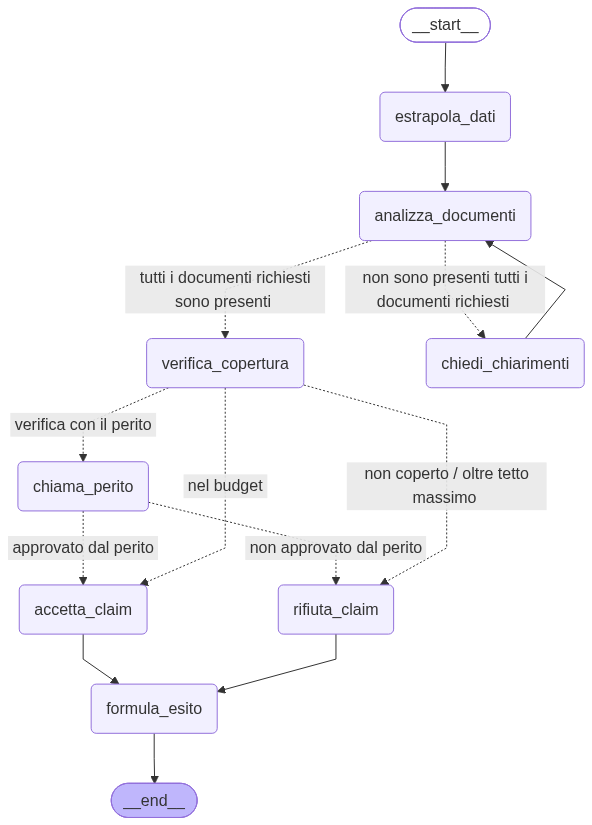

In [34]:
# Visualizza il grafo (richiede graphviz o pillow)
try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_mermaid())

In [36]:
print(review_claim_tool.func("ho bisogno di un reso, sono il cliente CL001", "CL001"))

Ciao! Sono qui per aiutarti.

Per iniziare, posso richiedere alcune informazioni per procedere con il tuo richiesta di reso. Purtroppo, non ho accesso alle tue informazioni personali, quindi ti chiedo di fornirmi i seguenti dettagli:

* Il numero di ordine o la referenza del prodotto che desideri restituire
* Il motivo del reso (ad esempio, prodotto difettoso, non corrispondente alle aspettative, ecc.)
* Il tuo codice cliente (CL001) e la tua email/numero di telefono per poter contattarti in caso di domande o necessità di ulteriore assistenza

Una volta che avrò queste informazioni, sarò in grado di procedere con il tuo richiesta di reso e fornirti le informazioni necessarie per completare il processo.

Se hai già ricevuto un codice di reso o una referenza unica, per favore condividalo con me.
